In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from multiprocessing import Pool

def mandelbrot_pixel(c, max_iter):
    z = 0
    for n in range(max_iter):
        if abs(z) > 2:
            return n
        z = z*z + c
    return max_iter

def mandelbrot_worker(args):
    c, max_iter = args
    return mandelbrot_pixel(c, max_iter)

def compute_mandelbrot_chunk(c_values, max_iter):
    """Computes iterations for a list/array of complex numbers."""
    return [mandelbrot_pixel(c, max_iter) for c in c_values]

In [2]:
def run_multiprocessing_mandelbrot(width, height, num_processors, chunksize):
    # 1. Define region and create grid
    x = np.linspace(-2.0, 1.0, width)
    y = np.linspace(-1.5, 1.5, height)
    X, Y = np.meshgrid(x, y)
    c_grid = (X + 1j*Y).flatten()
    
    max_iter = 100 # Typical value
    
    start_time = time.time()
    
    # 2. Parallel execution using a Pool
    with Pool(processes=num_processors) as pool:
        # Use a top-level worker (picklable on Windows/Jupyter)
        task_iter = ((c, max_iter) for c in c_grid)
        results = pool.map(
            mandelbrot_worker,
            task_iter,
            chunksize=chunksize
        )
    
    end_time = time.time()
    runtime = end_time - start_time
    
    # 3. Reshape results back to 2D array
    return np.array(results).reshape((height, width)), runtime

In [3]:
results_data = []
resolutions = [512, 1024]
processor_counts = [1, 2, 4, 8]
chunksizes = [1, 10, 100, 1000]

for p in processor_counts:
    for cs in chunksizes:
        img, duration = run_multiprocessing_mandelbrot(1024, 1024, p, cs)
        results_data.append({"P": p, "ChunkSize": cs, "Time": duration})
        print(f"P={p}, Chunk={cs}: {duration:.4f}s")


P=1, Chunk=1: 64.4803s
P=1, Chunk=10: 12.5791s
P=1, Chunk=100: 6.2222s
P=1, Chunk=1000: 4.9906s
P=2, Chunk=1: 158.6185s
P=2, Chunk=10: 19.5455s
P=2, Chunk=100: 5.1521s
P=2, Chunk=1000: 3.7339s
P=4, Chunk=1: 78.7142s
P=4, Chunk=10: 11.4929s
P=4, Chunk=100: 5.0053s
P=4, Chunk=1000: 4.1142s
P=8, Chunk=1: 79.2816s
P=8, Chunk=10: 12.6247s
P=8, Chunk=100: 5.2712s
P=8, Chunk=1000: 4.3193s


Calculation complete in 5.14 seconds.


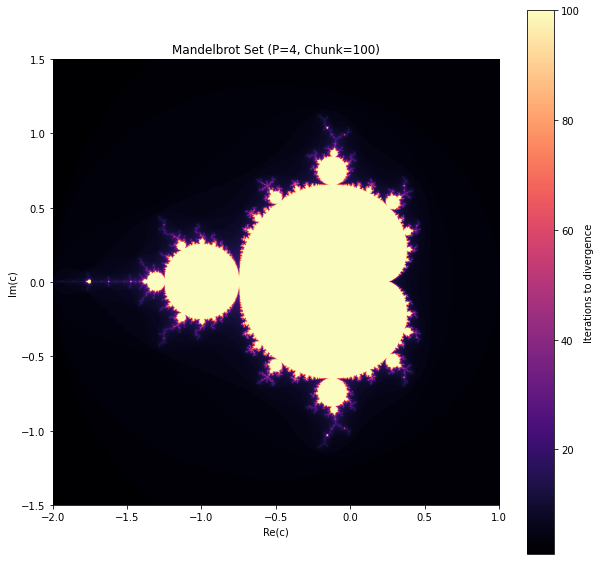

In [4]:
# Parameters based on project guidelines
width, height = 1024, 1024  # Resolution
num_processors = 4          # Number of processes (P)
chunksize = 100             # Adjusting this for scaling analysis
# Run the function
mandelbrot_set, duration = run_multiprocessing_mandelbrot(width, height, num_processors, chunksize)

print(f"Calculation complete in {duration:.2f} seconds.")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 10))
plt.imshow(mandelbrot_set, extent=[-2.0, 1.0, -1.5, 1.5], cmap='magma')
plt.colorbar(label='Iterations to divergence')
plt.title(f"Mandelbrot Set (P={num_processors}, Chunk={chunksize})")
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")
plt.show()